In [1]:
import numpy as np
import mojito
from mojito.reader import MojitoL1File
from mojito.download import download_brick, get_source_params
from mojito.orbits import interp_response_orbital_quantities
from mojito.download import download_catalog
import matplotlib.pyplot as plt
from MojitoProcessor import process_pipeline
import lisaconstants as lc 
import h5py as h5

/Users/diganta/Desktop/Papers/Mojito_search/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Make sure to define the environment variables MOJITO_USERNAME and MOJITO_TOKEN, for mac users this should go into your .zshrc file.

In [5]:
# Download the combined dataset 
noise_dataset = download_brick("noise", reduced=True)
noise_dataset

WARNING! Reduced versions are not official L1 files and are not representative of real data, as sampling rates are not correct and some quantities might be missing. Use them only for testing and development purposes.
WARNING! Publications using Mojito data are currently not allowed! Please keep in touch, as publication policies will soon be published.


'/Users/diganta/.mojito_cache/brickmarket/mojito_light_v1_0_0/data/INSTRUMENT/L1_0p4Hz/NOISE_731d_2.5s_L1_source0_0_20251206T220508924302Z.h5'

In [6]:
# Augment the data with the metadata of the central frequency of the laser 
# Laser carrier frequency is 
# 281.76 THz
# https://journals.aps.org/prd/pdf/10.1103/PhysRevD.109.022004 : 1064nm wavelength 

wavelength = 1064e-9  # meters

f_carrier = lc.c / wavelength  # Hz
f_carrier

281759828947368.4

In [8]:
mojito_data_file = noise_dataset  # Path to your Mojito L1 HDF5 file


with MojitoL1File(mojito_data_file) as f:
    tdi_sampling = f.tdis.time_sampling
    data = {
        "tdis": {
            "X": f.tdis.x2[:],
            "Y": f.tdis.y2[:],
            "Z": f.tdis.z2[:],
        },
        "fs":    tdi_sampling.fs,
        "t_tdi": tdi_sampling.t()[:],
        "metadata":{"laser_frequency":f_carrier}
    }

In [9]:
# ── Pipeline parameters ───────────────────────────────────────────────────────

# Downsampling parameters
downsample_kwargs = {
    "target_fs": 0.2,      # Hz — target sampling rate (None = no downsampling)
    "kaiser_window": 31.0, # Kaiser window beta (higher = more aggressive anti-aliasing)
}

# Filter parameters
filter_kwargs = {
    "highpass_cutoff": 5e-6,                               # Hz — high-pass cutoff (always applied)
    "lowpass_cutoff":1.e-1,  # Hz — low-pass cutoff (None for high-pass only)
    "order": 2,                                            # Butterworth filter order
}

# Trim parameters
trim_kwargs = {}
#    "fraction": 0.00,  # Total fraction of data trimmed symmetrically from both ends
#}

# Segmentation parameters
# selects the first ``truncate_days`` of the processed data
truncate_kwargs = {}
    #"days": 0.0,  # Segment length in days (splits dataset into non-overlapping chunks) 
#}

# Window parameters
window_kwargs = {
    "window": "tukey",  # Window type: 'tukey', 'hann', 'hamming', 'blackman'
    "alpha": 0.0125,    # Taper fraction for Tukey window
}
# ─────────────────────────────────────────────────────────────────────────────

processed_segments = process_pipeline(
    data,
    downsample_kwargs=downsample_kwargs,
    filter_kwargs=filter_kwargs,
    trim_kwargs=trim_kwargs,
    truncate_kwargs=truncate_kwargs,
    window_kwargs=window_kwargs,
)

# Access processed data
sp = processed_segments["segment0"]
print(f"Sampling rate: {sp.fs} Hz")
print(f"Duration:      {sp.T/86400:.2f} days")
print(f"TCB start:     {sp.t0} s")

Sampling rate: 0.2 Hz
Duration:      730.51 days
TCB start:     97729939.827664 s


In [10]:
print('shape of data: ',sp.data['X'].shape)

shape of data:  (12623240,)


In [11]:
dt = 1/sp.fs
print('Duration in years:', sp.T/(lc.ASTRONOMICAL_YEAR))

Duration in years: 1.9999968462317361


In [12]:
AET = sp.to_aet()

data_array = np.array([sp.t, AET.data['A'], AET.data['E'], AET.data['T']])

In [13]:
np.save('mojito_noise_data.npy',data_array)

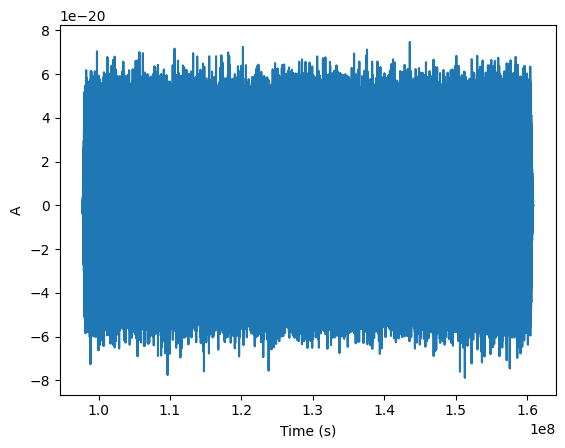

In [14]:
plt.plot(sp.t,AET.data['A'])
plt.xlabel('Time (s)')
plt.ylabel('A')
plt.show()

In [15]:
sp.periodogram()

(array([0.00000000e+00, 1.58437929e-08, 3.16875858e-08, ...,
        9.99999683e-02, 9.99999842e-02, 1.00000000e-01], shape=(6311621,)),
 {'X': array([2.70569035e-40, 5.41023331e-40, 5.40572298e-40, ...,
         4.74937925e-39, 6.18770204e-40, 4.40305497e-39], shape=(6311621,)),
  'Y': array([6.96044369e-41, 1.39246729e-40, 1.39319305e-40, ...,
         7.93203265e-39, 1.87190596e-39, 4.30968712e-40], shape=(6311621,)),
  'Z': array([3.26821326e-40, 6.53758403e-40, 6.54129797e-40, ...,
         1.82788246e-39, 9.70336277e-40, 4.88052619e-40], shape=(6311621,))})